<a href="https://colab.research.google.com/github/Sythaz/PCVK_Ganjil_2024/blob/main/PCVK_Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum**

## ***Nomor 1***

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


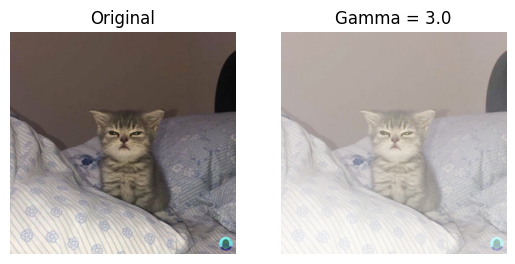

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except:
    print('Error, not a number')

# Membaca gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/kitten01.jpg')   # 0 = grayscale
if img is None:
    raise FileNotFoundError('File tidak ditemukan.')

# Rumus gamma correction: I’ = 255 * (I/255)^(1/gamma)
c = 255.0 / (255.0 ** (1.0/gamma))

# Menerapkan gamma correction pada tiap channel
gamma_img = c * (img.astype(np.float64) ** (1.0/gamma))
gamma_img = np.uint8(np.clip(gamma_img, 0, 255))

# Menampilkan hasil
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f'Gamma = {gamma}')
plt.imshow(cv2.cvtColor(gamma_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## ***Nomor 2***

 Simulasi Image Depth 
----------------------------------
Masukkan bit depth (contoh modul: 2): 2


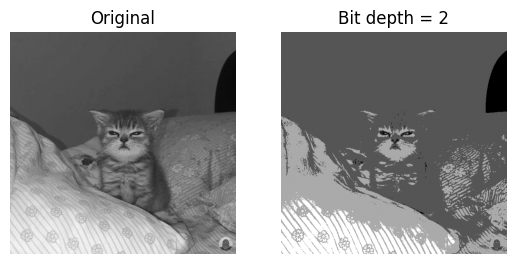

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(' Simulasi Image Depth ')
print('----------------------------------')
try:
    bit_depth = int(input('Masukkan bit depth (contoh modul: 2): '))
except:
    print('Error, not a number')

# Baca gambar grayscale
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/kitten01.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError('File tidak ditemukan.')

# Hitung jarak antar-level sesuai modul
level = 255 / (pow(2, bit_depth) - 1)

# Pre-alloc output sama shape
depth_img = np.zeros(img.shape, dtype=np.uint8)

# Isi per-pixel (loop sesuai modul)
h, w = img.shape
for y in range(h):
    for x in range(w):
        val = img[y, x]
        q = np.round(val / level) * level
        if q < 0:
            q = 0
        elif q > 255:
            q = 255
        depth_img[y, x] = np.uint8(q)

# Tampilkan hasil
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f'Bit depth = {bit_depth}')
plt.imshow(depth_img, cmap='gray')
plt.axis('off')
plt.show()

## ***Nomor 3***

In [6]:
import cv2
import numpy as np
import glob
import os

# Fungsi PSNR sesuai modul
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# Membaca citra original
orig = cv2.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
if orig is None:
    raise FileNotFoundError('File original tidak ditemukan.')

# Folder output untuk simpan citra noise
noise_dir = '/content/drive/MyDrive/PCVK/Images/noises/'
os.makedirs(noise_dir, exist_ok=True)

# Buat 100 citra noise dari original
num_noises = 100
for i in range(num_noises):
    noise = np.random.normal(0, 25, orig.shape).astype(np.float64)  # mean=0, std=25
    noisy_img = orig.astype(np.float64) + noise
    noisy_img = np.uint8(np.clip(noisy_img, 0, 255))
    cv2.imwrite(f'{noise_dir}noise_{i+1}.jpg', noisy_img)

print("100 citra noise berhasil dibuat.")

# Membaca semua citra noise
files = glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg')
files.sort()

jumlah = [5, 10, 20, 40, 80, 100]
for n in jumlah:
    acc = np.zeros(orig.shape, dtype=np.float64)
    for f in files[:n]:
        im = cv2.imread(f).astype(np.float64)
        acc += im
    avg = acc / n
    avg_img = np.uint8(np.clip(avg, 0, 255))
    psnr = PSNR(orig, avg_img)
    print(f'Jumlah citra = {n}, PSNR = {psnr:.2f} dB')
    # Create the output directory if it doesn't exist
    output_dir = '/content/drive/MyDrive/PCVK/Images/output/'
    os.makedirs(output_dir, exist_ok=True)
    cv2.imwrite(f'{output_dir}average_{n}.png', avg_img)

100 citra noise berhasil dibuat.
Jumlah citra = 5, PSNR = 29.51 dB
Jumlah citra = 10, PSNR = 31.02 dB
Jumlah citra = 20, PSNR = 32.04 dB
Jumlah citra = 40, PSNR = 32.65 dB
Jumlah citra = 80, PSNR = 32.99 dB
Jumlah citra = 100, PSNR = 33.07 dB


## ***Nomor 4***

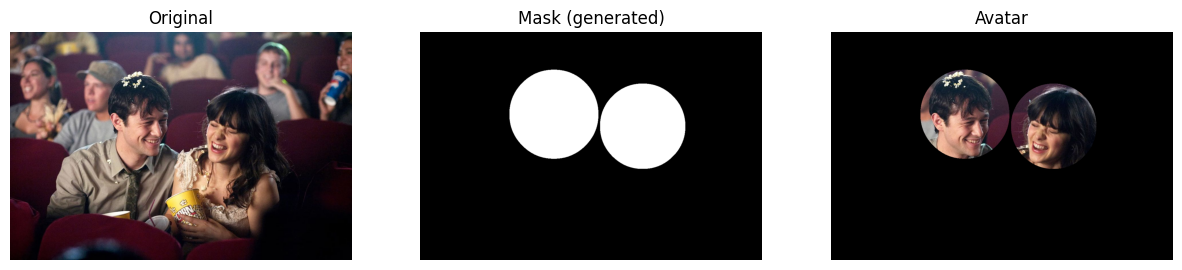

True

In [53]:
import cv2
import matplotlib.pyplot as plt

# Baca image dan mask
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/couple.jpg')
mask = cv2.imread('/content/drive/MyDrive/PCVK/Images/mask.jpg', 0)  # grayscale

if img is None or mask is None:
    raise FileNotFoundError("Image atau Mask tidak ditemukan.")

# Pastikan mask biner (0 / 255)
_, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

# Ubah mask ke 3 channel supaya cocok dengan citra warna
mask3 = cv2.merge([mask_bin, mask_bin, mask_bin])

# Hasil avatar = citra asli AND mask
avatar = cv2.bitwise_and(img, mask3)

# Tampilkan
plt.figure(figsize=(15,15))
plt.subplot(1,3,1); plt.title('Original'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,3,2); plt.title('Mask (generated)'); plt.imshow(mask_bin, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title('Avatar'); plt.imshow(cv2.cvtColor(avatar, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()

# Simpan hasil avatar
cv2.imwrite('/content/drive/MyDrive/PCVK/Images/avatarMasking.png', avatar)

## ***Nomor 5***

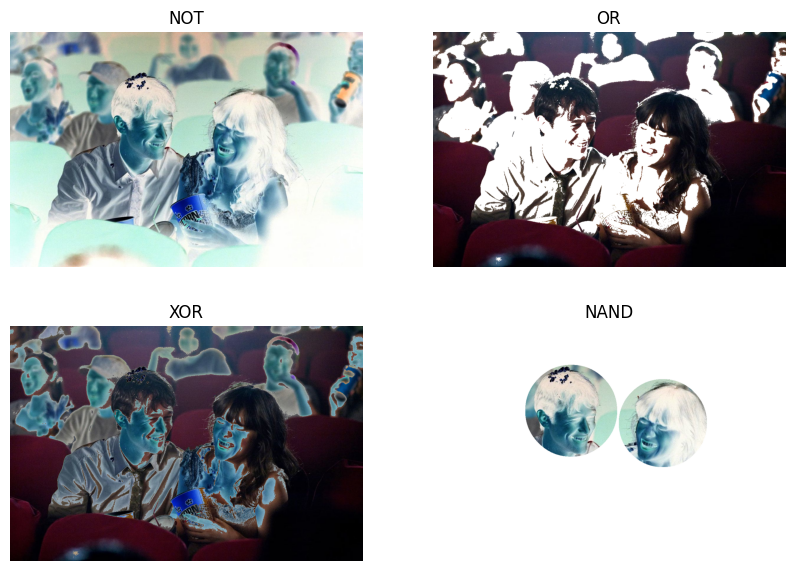

In [72]:
# NOT
not_img = cv2.bitwise_not(img)

# OR
or_img = cv2.bitwise_or(img, mask3)

# XOR
xor_img = cv2.bitwise_xor(img, mask3)

# NAND = NOT(AND)
nand_img = cv2.bitwise_not(masked)

# Simpan hasil
cv2.imwrite('/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_not.png', not_img)
cv2.imwrite('/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_or.png', or_img)
cv2.imwrite('/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_xor.png', xor_img)
cv2.imwrite('/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_nand.png', nand_img)

# Load the saved images
loaded_not = cv2.imread(f'/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_not.png')
loaded_or = cv2.imread(f'/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_or.png')
loaded_xor = cv2.imread(f'/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_xor.png')
loaded_nand = cv2.imread(f'/content/drive/MyDrive/PCVK/Images/outputOperatorLain/op_nand.png')


plt.figure(figsize=(10,7))
plt.subplot(2,2,1); plt.title('NOT'); plt.imshow(cv2.cvtColor(loaded_not, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(2,2,2); plt.title('OR'); plt.imshow(cv2.cvtColor(loaded_or, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(2,2,3); plt.title('XOR'); plt.imshow(cv2.cvtColor(loaded_xor, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(2,2,4); plt.title('NAND'); plt.imshow(cv2.cvtColor(loaded_nand, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()